In [ ]:

# --- 1. Importer og seed ---
import random
import numpy as np
import matplotlib.pyplot as plt
import pickle, json
from pathlib import Path
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# --- 2. Monter Drive ---
import os
from google.colab import drive

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

PROCESSED = Path("/content/drive/MyDrive/processed")
print("Filer:", [f.name for f in PROCESSED.iterdir()])

Mounted at /content/drive
Filer: ['X_val.npy', 'y_train.npy', 'y_val.npy', 'y_test.npy', 'label_encoder.pkl', 'X_test.npy', 'X_train.npy', 'baseline_best.keras', 'baseline_training_curves.png', 'baseline_confusion_matrix.png', 'baseline_resultater.json', 'improved_best.keras', 'improved_training_curves.png', 'improved_confusion_matrix.png', 'improved_resultater.json', 'X_train_fusion.npy', 'y_val_fusion.npy', 'X_val_fusion.npy', 'X_test_fusion.npy', 'y_train_fusion.npy', 'y_test_fusion.npy']


In [ ]:
# --- 3. Last inn fusion-data ---
X_train = np.load(PROCESSED / "X_train_fusion.npy")
y_train = np.load(PROCESSED / "y_train_fusion.npy")
X_val   = np.load(PROCESSED / "X_val_fusion.npy")
y_val   = np.load(PROCESSED / "y_val_fusion.npy")
X_test  = np.load(PROCESSED / "X_test_fusion.npy")
y_test  = np.load(PROCESSED / "y_test_fusion.npy")

with open(PROCESSED / "label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

NUM_CLASSES = len(le.classes_)
INPUT_SHAPE = X_train.shape[1:]  # (128, 130, 3)

print(f"X_train shape : {X_train.shape}")
print(f"Input shape   : {INPUT_SHAPE}")
print(f"Klasser ({NUM_CLASSES}): {list(le.classes_)}")

X_train shape : (4695, 128, 130, 3)
Input shape   : (128, 130, 3)
Klasser (11): [np.str_('cel'), np.str_('cla'), np.str_('flu'), np.str_('gac'), np.str_('gel'), np.str_('org'), np.str_('pia'), np.str_('sax'), np.str_('tru'), np.str_('vio'), np.str_('voi')]


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


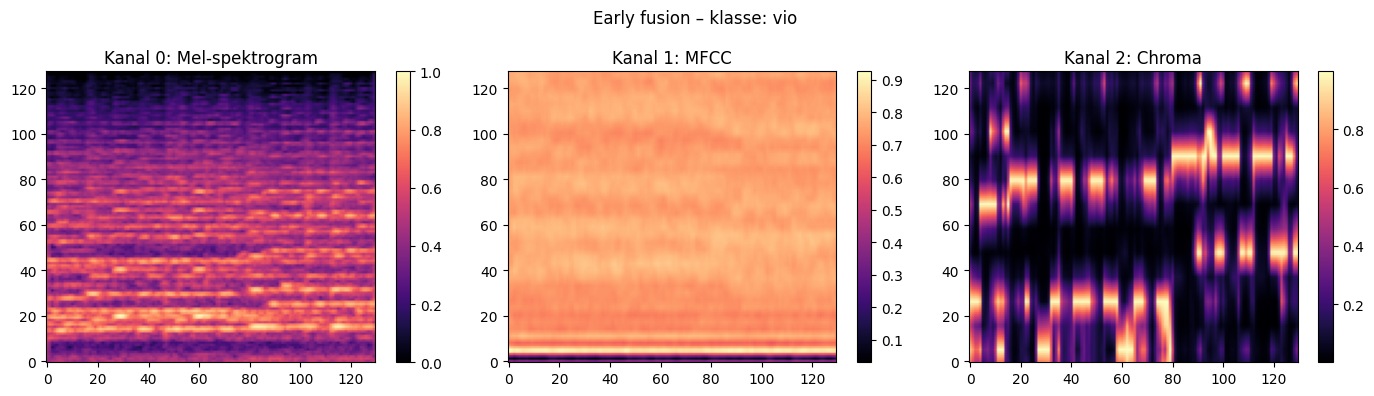

In [ ]:
# --- 4. Visualiser de tre kanalene for ett eksempel ---
sample = X_train[0]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titles = ["Kanal 0: Mel-spektrogram", "Kanal 1: MFCC", "Kanal 2: Chroma"]

for i, (ax, title) in enumerate(zip(axes, titles)):
    im = ax.imshow(sample[:, :, i], aspect='auto',
                   origin='lower', cmap='magma')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.suptitle(f"Early fusion – klasse: {le.classes_[y_train[0]]}")
plt.tight_layout()
plt.show()

In [ ]:
# --- 5. Bygg fusion CNN ---
# Samme arkitektur som baseline, men input har 3 kanaler
def build_fusion_cnn(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = inputs

    for filters in [32, 64, 128]:
        x = layers.Conv2D(filters, (3, 3), padding='same',
                          kernel_initializer='he_uniform')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(256, (3, 3), padding='same',
                      kernel_initializer='he_uniform')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name="fusion_cnn")

model = build_fusion_cnn(INPUT_SHAPE, NUM_CLASSES)
model.summary()

Model: "fusion_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 130, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 130, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 130, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 130, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 65, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 65, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 393,163 (1.50 MB)

 Trainable params: 392,203 (1.50 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# --- 6. Kompiler ---
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# --- 7. Callbacks ---
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint(
        str(PROCESSED / "fusion_best.keras"),
        monitor='val_loss', save_best_only=True, verbose=1)
]

In [ ]:
# --- 8. Tren ---
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=32,
    callbacks=callbacks, verbose=1
)

Epoch 1/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.2241 - loss: 2.2453
Epoch 1: val_loss improved from None to 2.72965, saving model to /content/drive/MyDrive/processed/fusion_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/processed/fusion_best.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 78ms/step - accuracy: 0.2709 - loss: 2.1091 - val_accuracy: 0.2191 - val_loss: 2.7296 - learning_rate: 0.0010
Epoch 2/100
145/147 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3432 - loss: 1.9065
Epoch 2: val_loss did not improve from 2.72965
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.3753 - loss: 1.8291 - val_accuracy: 0.1624 - val_loss: 2.8760 - learning_rate: 0.0010
Epoch 3/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4137 - loss: 1.7313
Epoch 3: val_loss improved from 2.72965 to 2.09627, saving model to /content/drive/MyDrive/processed/fusion_best.keras

Epoch 3: finished saving model to /content/drive/MyDrive/processed/fusion_best.ker

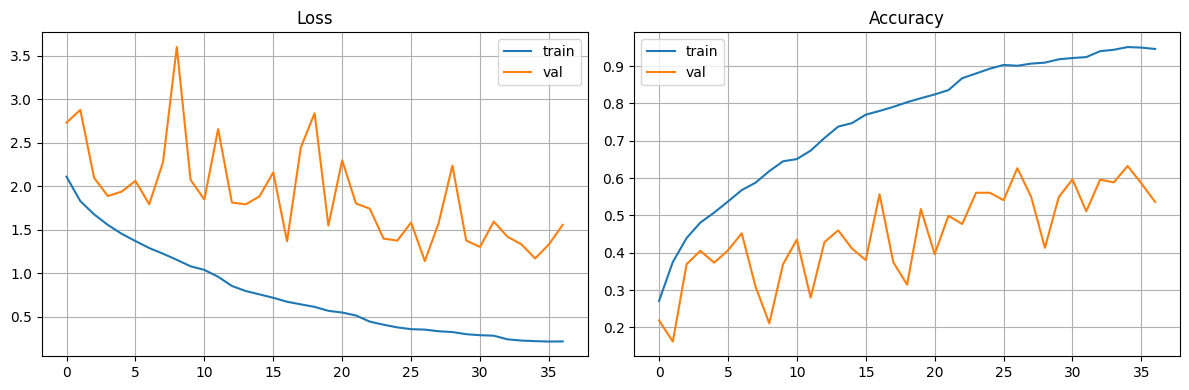

In [ ]:
# --- 9. Treningskurver ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'],     label='train')
ax1.plot(history.history['val_loss'], label='val')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(True)

ax2.plot(history.history['accuracy'],     label='train')
ax2.plot(history.history['val_accuracy'], label='val')
ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig(PROCESSED / "fusion_training_curves.png", dpi=150)
plt.show()

In [ ]:
# --- 10. Evaluer ---
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest loss    : {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print(classification_report(y_test, y_pred, target_names=le.classes_))


Test loss    : 1.1868
Test accuracy: 0.6243
              precision    recall  f1-score   support

         cel       0.66      0.57      0.61        58
         cla       0.52      0.58      0.55        76
         flu       0.52      0.68      0.59        68
         gac       0.79      0.47      0.59        96
         gel       0.78      0.46      0.57       114
         org       0.81      0.59      0.68       102
         pia       0.76      0.85      0.80       108
         sax       0.34      0.64      0.45        94
         tru       0.70      0.57      0.63        86
         vio       0.50      0.62      0.55        87
         voi       0.85      0.79      0.82       117

    accuracy                           0.62      1006
   macro avg       0.66      0.62      0.62      1006
weighted avg       0.67      0.62      0.63      1006



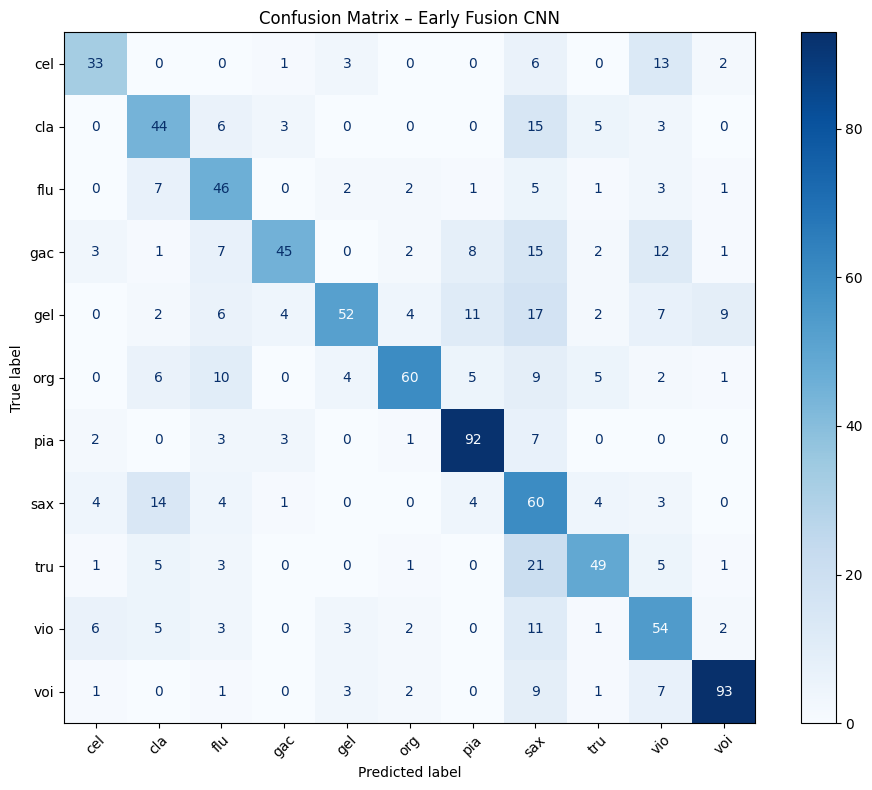

In [ ]:
# --- 11. Confusion matrix ---
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=le.classes_,
    xticks_rotation=45, cmap='Blues', ax=ax)
plt.title("Confusion Matrix – Early Fusion CNN")
plt.tight_layout()
plt.savefig(PROCESSED / "fusion_confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
# --- 12. Sammenlign med baseline ---
baseline = json.load(open(PROCESSED / "baseline_resultater.json"))

print(f"\n{'Modell':<25} {'Test Acc':>10}")
print("-" * 37)
print(f"{'Dummy':<25} {baseline['dummy_accuracy']:>10.4f}")
print(f"{'Baseline CNN (mel)':<25} {baseline['test_accuracy']:>10.4f}")
print(f"{'Early Fusion CNN':<25} {test_acc:>10.4f}")


Modell                      Test Acc
-------------------------------------
Dummy                         0.1163
Baseline CNN (mel)            0.7286
Early Fusion CNN              0.6243


In [ ]:
# --- 13. Lagre resultater ---
resultater = {
    "test_loss":     float(test_loss),
    "test_accuracy": float(test_acc),
    "epoker_trent":  len(history.history['loss']),
    "input_shape":   list(INPUT_SHAPE),
    "features":      ["mel", "mfcc", "chroma"],
    "klasser":       list(le.classes_)
}

with open(PROCESSED / "fusion_resultater.json", "w") as f:
    json.dump(resultater, f, indent=2)

print("Resultater lagret!")
print(json.dumps(resultater, indent=2))

Resultater lagret!
{
  "test_loss": 1.1868342161178589,
  "test_accuracy": 0.6242544651031494,
  "epoker_trent": 37,
  "input_shape": [
    128,
    130,
    3
  ],
  "features": [
    "mel",
    "mfcc",
    "chroma"
  ],
  "klasser": [
    "cel",
    "cla",
    "flu",
    "gac",
    "gel",
    "org",
    "pia",
    "sax",
    "tru",
    "vio",
    "voi"
  ]
}
